# アルゴリズム論Ⅱ 

## 第1回：浮動小数点数・数値誤差・収束性

このノートブックでは、コンピュータ内で数値がどのように表現され、どのような計算誤差が発生するのか、そして数値計算における「収束」の挙動を事例を通して学びます。

---

## 1. 計算が合わない ... 浮動小数点数と2進数変換の罠

10進数の小数（例: 0.1）は、2進数に変換すると循環小数になるため、コンピュータ内では正確に表現できません。

### 1 + 2 = 3 は正しいが、0.1 + 0.2 = 0.3 は間違い？

In [33]:
print(1 + 2 == 3)

print(0.1 + 0.2 == 0.3)


True
False


### 0.1 を 1000 回足すと 100 ですよね？

In [34]:
# 0.1 を 1000 回足す計算
total = 0.0
for _ in range(1000):
    total += 0.1

print(f"計算結果: {total}")
print(f"理想的な結果 (100.0) と一致するか?: {total == 100.0}")
print(f"誤差: {total - 100.0:.20f}")

計算結果: 99.9999999999986
理想的な結果 (100.0) と一致するか?: False
誤差: -0.00000000000140687462


### Pythonの `struct` モジュールで、コンピュータ内部の2進数（IEEE 754）をのぞいてみる

In [11]:
import struct

def float_to_bin32(val: float) -> str:
    """32bit(単精度)浮動小数点数のビットパターンを取得"""
    packed = struct.pack('>f', val)
    [integ] = struct.unpack('>I', packed)
    bin_str = f"{integ:032b}"
    return f"符号: {bin_str[0]} | 指数部: {bin_str[1:9]} | 仮数部: {bin_str[9:]}"

print("0.25（正確に表現可能） :\t",  float_to_bin32(0.25))
print("0.1 （循環小数・近似値）:\t",  float_to_bin32(0.1))
print("0.8125（正確に表現可能） :\t", float_to_bin32(0.8125))
print("0.812（循環小数・近似値）:\t",  float_to_bin32(0.812))

0.25（正確に表現可能） :	 符号: 0 | 指数部: 01111101 | 仮数部: 00000000000000000000000
0.1 （循環小数・近似値）:	 符号: 0 | 指数部: 01111011 | 仮数部: 10011001100110011001101
0.8125（正確に表現可能） :	 符号: 0 | 指数部: 01111110 | 仮数部: 10100000000000000000000
0.812（循環小数・近似値）:	 符号: 0 | 指数部: 01111110 | 仮数部: 10011111101111100111011


---

## 2. コンピュータにおける様々な数値誤差

計算の順序や式の形によって生じる典型的な誤差（桁落ち・情報落ち）を確認します。

### 桁落ち (Cancellation)

値が非常に近い2つの数の**引き算**を行うと、有効数字が大きく失われます。
* 例: $x = 10^{15}$ のときの $f(x) = \sqrt{x+1} - \sqrt{x}$

（式を変形して、$f(x) = \frac{1}{\sqrt{x + 1} + \sqrt{x}} $ とすれば、計算誤差を回避できる）


In [15]:
import math

x = 1.0e15

# そのまま計算（桁落ちが発生）
direct_calc = math.sqrt(x + 1) - math.sqrt(x)
print(f"そのままの式で計算の結果  : {direct_calc:.15e}")

# 式を変形して計算:（桁落ちを回避）
reformed_calc = 1.0 / (math.sqrt(x + 1) + math.sqrt(x))
print(f"式を変形して計算した結果  : {reformed_calc:.15e}")

そのままの式で計算の結果  : 1.862645149230957e-08
式を変形して計算した結果  : 1.581138830084189e-08



### 情報落ち (Loss of Significance)

非常に大きい数に極めて小さい数を加減算すると、小さい数が計算結果に反映されない現象です。

In [16]:
large_num = 1e16
small_num = 1.0

# 大きい数に小さい数を足してから引く
result1 = (large_num + small_num) - large_num

# 小さい数同士を先に計算してから足す（計算順序の考慮）
result2 = small_num + (large_num - large_num)

print(f"(1e16 + 1.0) - 1e16 の結果 : {result1}")
print(f"普通に考えたらこの結果        : {small_num}")

(1e16 + 1.0) - 1e16 の結果 : 0.0
普通に考えたらこの結果        : 1.0


## 収束計算なにか。exp の計算とか？


---

## 3. 収束のスピード（一次収束 vs 二次収束）

方程式 $f(x) = x^2 - 2 = 0$ の解（$\sqrt{2} \approx 1.41421356...$）を求める2つの方法で、収束速度の違いをプロットして比較します。

* **二分法 (Bisection Method)**: 一次収束（ステップごとに誤差が約 $1/2$ になる）
* **ニュートン法 (Newton-Raphson Method)**: 二次収束（ステップごとに正確な桁数が約2倍になる）

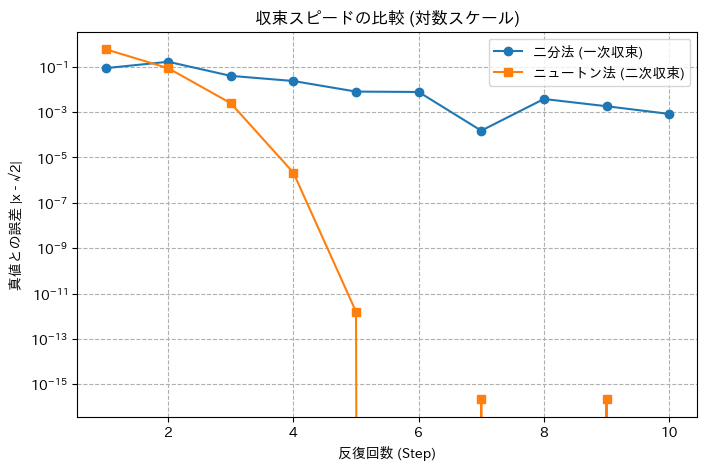

In [18]:
import math
import matplotlib.pyplot as plt
import japanize_matplotlib

target = math.sqrt(2)

# 1. 二分法
a, b = 1.0, 2.0
errors_bisection = []
for _ in range(10):
    mid = (a + b) / 2.0
    errors_bisection.append(abs(mid - target))
    if mid**2 - 2 > 0:
        b = mid
    else:
        a = mid

# 2. ニュートン法: x_{k+1} = x_k - (x_k^2 - 2) / (2 * x_k)
x = 2.0
errors_newton = []
for _ in range(10):
    errors_newton.append(abs(x - target))
    x = x - (x**2 - 2) / (2 * x)

# 誤差の推移を対数スケールでグラフ描画
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, 11), errors_bisection, label='二分法 (一次収束)', marker='o')
plt.semilogy(range(1, 11), errors_newton, label='ニュートン法 (二次収束)', marker='s')
plt.title("収束スピードの比較 (対数スケール)")
plt.xlabel("反復回数 (Step)")
plt.ylabel("真値との誤差 |x - √2|")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

## 4. 計算量

計算量（オーダー記法：$O$ 記法）は、**「入力データの量（$N$）が増えたときに、処理時間や作業の手間がどれくらい増えるか」** を表す指標です。

### 日常の例で見る主な計算量

処理の手間がデータ量 $N$ に対してどう増えるかで分類します。

**$O(1)$［オー・ワン / 定数時間］**
  - **イメージ:** データ量が増えても**一瞬**で終わる
  - **日常の例:** 番号がわかっているロッカーから荷物を取り出す    

**$O(\log N)$［オー・ログエヌ / 対数時間］**
  - **イメージ:** データが増えても**ほとんど増えない**
  - **日常の例:** 辞書で単語を二分探索（半分ずつ絞り込む）で探す  
  
  
**$O(N)$［オー・エヌ / 線形時間］**
  - **イメージ:** データ量に**比例して素直に増える**
  - **日常の例:** 名簿を上から順番に端から探す（線形探索）
  
  
**$O(N^2)$［オー・エヌ二乗 / 二乗時間］**
  - **イメージ:** データが増えると**急激に重くなる**
  - **日常の例:** クラス全員（$N$人）が全員同士でハイタッチする

**$O(2^N)$［オー・ニの エヌ乗 / 指数時間］**
  - **イメージ:** 爆発的に増え、**実用不能**になる
  - **日常の例:** $N$枚のコインのすべての裏表の組み合わせを試す
  
  
---

### なぜ計算量が大事なのか？

コンピューターの処理能力をもってしても、アルゴリズム（解き方）の効率が悪いと限界が来ます。

計算量を知ることで、データが巨大になっても「正しく現実的な時間で動くプログラム」を作ることができます。



---